# Constellation Detection — Project 1, Q5
**CS-GY 6643, Fall 2026** · **Names / NetIDs:** add before submission.

Classical image registration and partial constellation matching using the supplied data only. The requested public-leaderboard target is **0.93–0.95**; it is a target, not a measured result. Private performance is unknown.

Run from the project directory with the `Python (.venv)` kernel. Keep `constellation.py` beside this notebook and `Data/` beneath it. Install the pinned dependencies from `requirements.txt` if needed. The first run performs substantial image search; later runs reuse content-addressed evidence caches. Delete `outputs/q5/cache/` to force recomputation. All predictions are generated programmatically. Q1–Q4 and original inputs remain unchanged.

The shared implementation is [constellation.py](constellation.py), which also runs as `python constellation.py --data Data --output outputs/q5/submission_candidate.csv`. There are no external model weights or scene-name lookup tables.

For a new dataset without training scenes, reuse the fitted public-training calibration: `python constellation.py --data NEW_DATA --calibration outputs/q5/calibration.json --output submission.csv`. The new dataset must provide the same `patterns/`, `validation/`, and sample-submission layout; IDs and query counts are read dynamically.

## 1. Class concepts and method

| Foundation | Q5 use |
|---|---|
| Q1 / Lecture 1 intensity operations | Diagnose contrast and clipping; there is no Q5 target histogram to match |
| Q2 robust registration / intensity correction | Fit image gain and a smooth illumination plane after alignment |
| Q3 / Lecture 2 filtering | Gaussian background subtraction and local contrast normalization, preserving stars |
| Q4 normalized correlation / SIFT | Generate locations, search rotation and scale, then verify the aligned pixels |
| Lecture 3 transforms / consensus fitting | Match reference nodes to localized queries with outliers and missing stars |

The localizer combines SIFT proposals with a coarse full-image correlation search over rotations and scales. It refines promising transforms using OpenCV ECC (an implementation extension of normalized-correlation alignment), checks scale/shear and displacement, and compares fine texture and photometric residuals. A five-feature, regularized logistic calibration maps this evidence to a match score; it is an additional statistical adaptation, not a lecture recipe or a calibrated guarantee of probability.

Reference nodes come from white components; distance-transform peaks separate touching symbols. Two-point similarity hypotheses include reflection. One-to-one consensus matches are refined by affine least squares when sufficiently supported. Reference hypotheses are additionally checked against star-like structure at their projected nodes, using nearby offset positions as controls. The score discounts fitted correspondences and the extra matching opportunities in larger diagrams. This is a heuristic model-selection adaptation, not an official probability. A geometrically consistent figure may select a close alternative location and rescue a weak local match. Present off-figure patches remain present.

**Coordinates:** x is column and y is row. All outputs map the query center `(15.5, 15.5)` back to the original 3000×3000 sky; there is no wrapping. Coarse rotated templates use an interior region; pixel verification uses an interior disk to avoid transformed query borders.

In [1]:
from pathlib import Path
import ast, csv, hashlib, json
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
import constellation as cd

DATA = Path("Data")
OUT = Path("outputs/q5")
CACHE = OUT / "cache"
OUT.mkdir(parents=True, exist_ok=True)
cd.cv2.setNumThreads(2)
cd.cv2.setRNGSeed(7)

def read_rows(path):
    with path.open(newline="") as handle:
        return list(csv.DictReader(handle))

training_rows = read_rows(DATA / "train_ground_truth.csv")
sample_rows = read_rows(DATA / "sample_submission.csv")
input_hashes = {str(p): hashlib.sha256(p.read_bytes()).hexdigest()
                for p in sorted(DATA.rglob("*")) if p.is_file() and p.suffix in (".png", ".csv")}
print(f"{len(training_rows)} labeled scenes; {len(sample_rows)} competition scenes")
print(f"NumPy {np.__version__}; OpenCV {cd.cv2.__version__}")

Matplotlib is building the font cache; this may take a moment.


3 labeled scenes; 16 competition scenes
NumPy 2.5.3; OpenCV 5.0.0


## 2. Inspect the reference representation
The markers below are extracted from pixels, not supplied correspondences. Very small reference figures are geometrically ambiguous: this implementation declines to establish an identity from fewer than four nodes. Aspect changes are handled by refinement of supported hypotheses, not an exhaustive search over every possible affine transform.

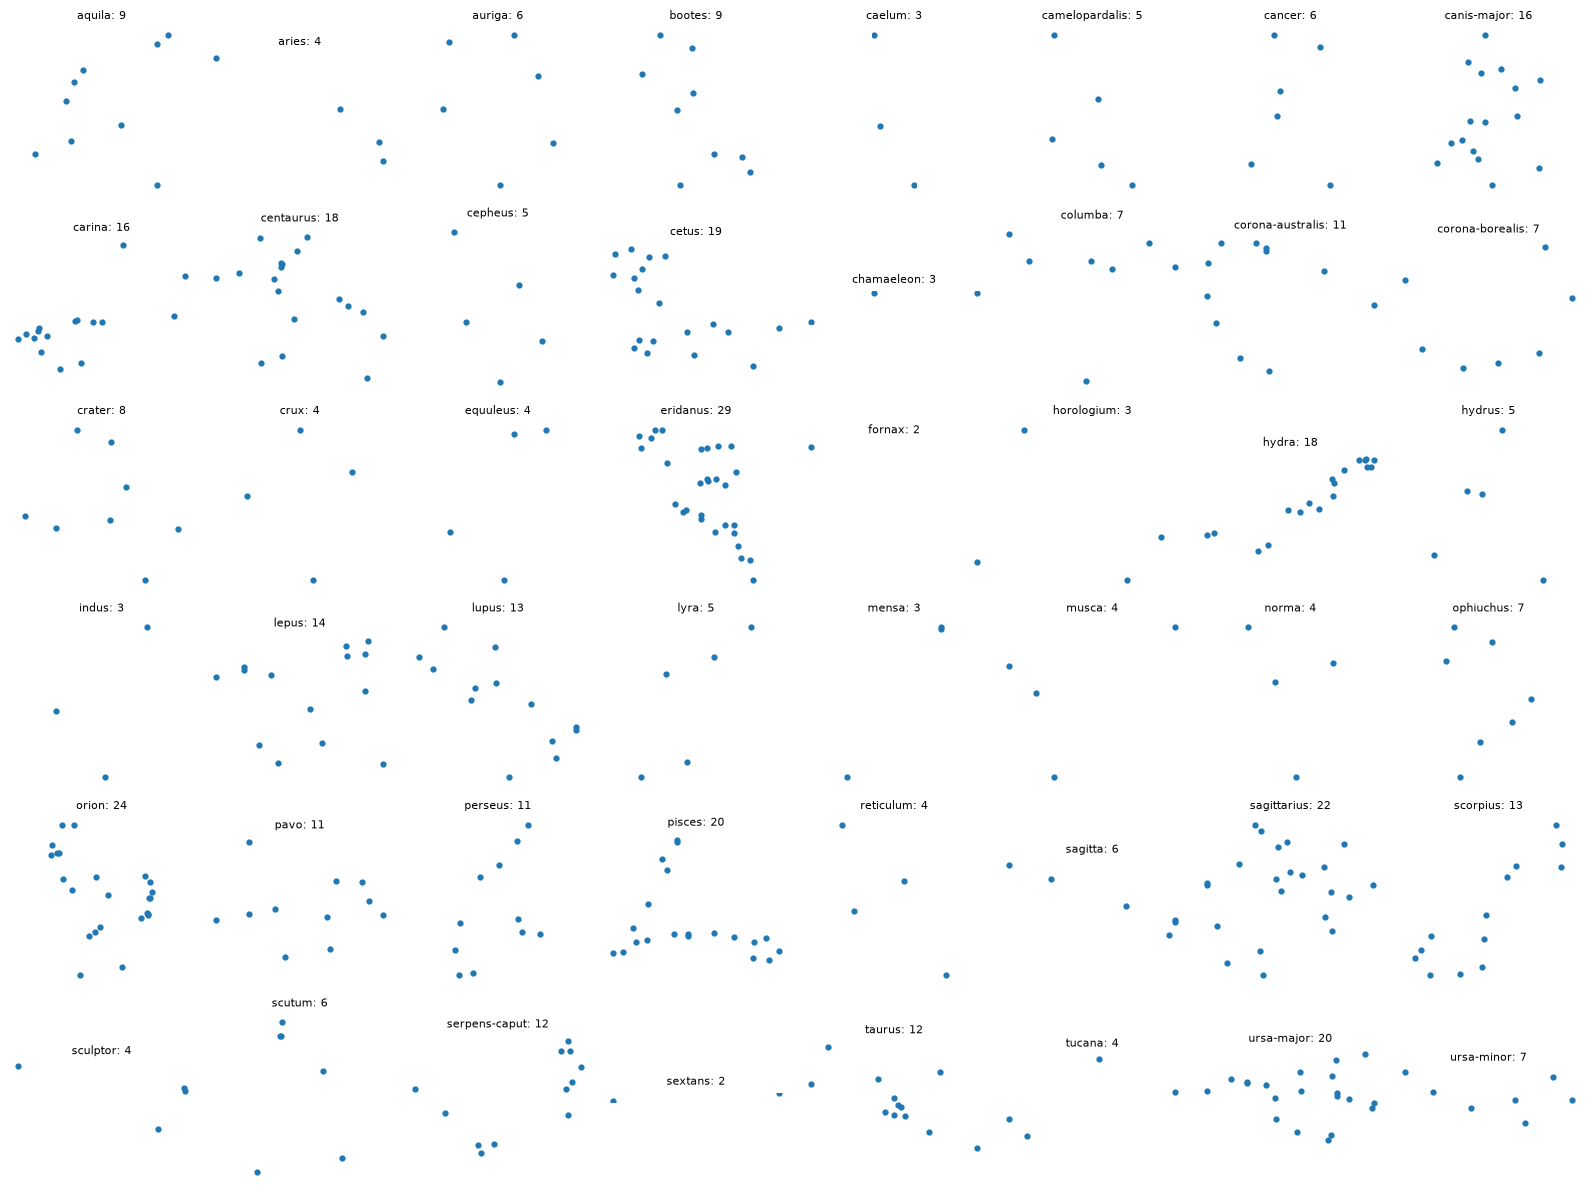

In [2]:
patterns = cd.read_patterns(DATA / "patterns")
fig, axes = plt.subplots(6, 8, figsize=(16, 12))
for ax, (name, nodes) in zip(axes.ravel(), patterns.items()):
    ax.scatter(nodes[:, 0], nodes[:, 1], s=12)
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.set_title(f"{name}: {len(nodes)}", fontsize=8)
    ax.axis("off")
fig.tight_layout()
plt.show()

## 3. Compute training evidence
Labels are used only for evaluation and fitting the five-feature calibration. Candidate generation and image refinement do not receive labels. Cached evidence is keyed by image bytes, matching-function source, and library versions.

In [3]:
training_evidence = {
    row["Id"]: cd.analyze_scene(DATA / "train" / row["Id"], CACHE)
    for row in training_rows
}
# Diagnostic only: is a correct location among the retained alternatives?
for row in training_rows:
    total = retained = first = 0
    for i, matches in enumerate(training_evidence[row["Id"]], 1):
        truth = ast.literal_eval(row[f"patch_{i:02}"])
        if truth == -1:
            continue
        total += 1
        distances = [np.hypot(m["x"]-truth[0], m["y"]-truth[1]) for m in matches]
        retained += any(d <= 12 for d in distances)
        first += bool(distances and distances[0] <= 12)
    print(f"{row['Id']}: first candidate {first}/{total}; retained candidate recall {retained}/{total}")

pisces: first candidate 25/27; retained candidate recall 27/27
scorpius: first candidate 22/26; retained candidate recall 26/26
taurus: first candidate 15/18; retained candidate recall 17/18


## 4. Hold one whole scene out of calibration
Each fold learns match calibration from the other two scenes. Image-matching and geometry settings are shared. These three scenes also informed development, so this is **development cross-validation**, not an untouched estimate of private-leaderboard accuracy.

The local scorer follows the handout: macro present/absent F1; localization reward of 1 within 12 pixels and 0 from 36 pixels; nearest-first one-to-one figure recovery against all predicted present points; exact constellation name. It is **not an official executable scorer**. Membership `m` is reported but its scoring role is unspecified. Our explicit local conventions are stable row-major ordering for distance ties, F1=1 for an empty class, and zero localization/geometry for empty ground-truth sets. The supplied training scenes have neither empty class.

The initial geometry tolerance is 24 pixels; final association allows 48 pixels to accommodate schematic drawing error. This wider association only chooses already localized image candidates; the 12-pixel localization target is unchanged. Geometric rescue is conditional on an image candidate and a consistent figure; it does not fabricate coordinates from the reference drawing.

In [4]:
cross_validation = {}
for row in training_rows:
    other_rows = [r for r in training_rows if r["Id"] != row["Id"]]
    calibration = cd.fit_calibration(*cd.calibration_data(other_rows, training_evidence))
    sky = cd.cv2.imread(str(DATA / "train" / row["Id"] / f"{row['Id']}_image.png"), 0)
    prediction = cd.predict_scene(training_evidence[row["Id"]], calibration, patterns, sky)
    cross_validation[row["Id"]] = {
        "prediction": prediction, "metrics": cd.score_scene(row, prediction)
    }
columns = ["Presence", "Localization", "GeometricRecovery", "Identification", "Score"]
table = "| Held-out scene | Predicted name | " + " | ".join(columns) + " |\n"
table += "|---|---|" + "---:|" * len(columns) + "\n"
for name, result in cross_validation.items():
    table += f"| {name} | {result['prediction']['constellation']} | "
    table += " | ".join(f"{result['metrics'][c]:.4f}" for c in columns) + " |\n"
display(Markdown(table))
mean_score = np.mean([r["metrics"]["Score"] for r in cross_validation.values()])
print(f"Mean development score: {mean_score:.4f}; Kaggle public/private scores: unmeasured")
(OUT / "cross_validation.json").write_text(json.dumps(cross_validation, indent=2))

| Held-out scene | Predicted name | Presence | Localization | GeometricRecovery | Identification | Score |
|---|---|---:|---:|---:|---:|---:|
| pisces | pisces | 0.9172 | 0.9630 | 1.0000 | 1.0000 | 0.9719 |
| scorpius | scorpius | 0.9458 | 1.0000 | 1.0000 | 1.0000 | 0.9864 |
| taurus | taurus | 0.9412 | 0.8333 | 1.0000 | 1.0000 | 0.9520 |


Mean development score: 0.9701; Kaggle public/private scores: unmeasured


122879

## 5. Review competing identities and unresolved matches
A scene can contain other recognizable star configurations. A larger geometric consensus can therefore name a competing constellation. Closely tied image matches also occur at distant positions. These are real limitations to inspect rather than resolve through scene-specific constants or manual coordinates.


 pisces top geometric hypotheses:
pisces support 7 median error 2.36 evidence 1.5
pavo support 5 median error 9.95 evidence 0.86
corona-borealis support 4 median error 1.92 evidence 0.84
Failures: [(22, 'missed present'), (25, 'false present'), (30, 'false present')]

 scorpius top geometric hypotheses:
scorpius support 10 median error 5.9 evidence 2.97
lupus support 5 median error 4.1 evidence 1.2
hydrus support 4 median error 3.14 evidence 0.88
Failures: [(4, 'false present'), (34, 'false present')]

 taurus top geometric hypotheses:
taurus support 7 median error 5.12 evidence 1.9
orion support 10 median error 6.28 evidence 1.75
hydrus support 4 median error 5.01 evidence 0.85
Failures: [(12, 'localization 759.5px'), (18, 'missed present'), (29, 'missed present')]


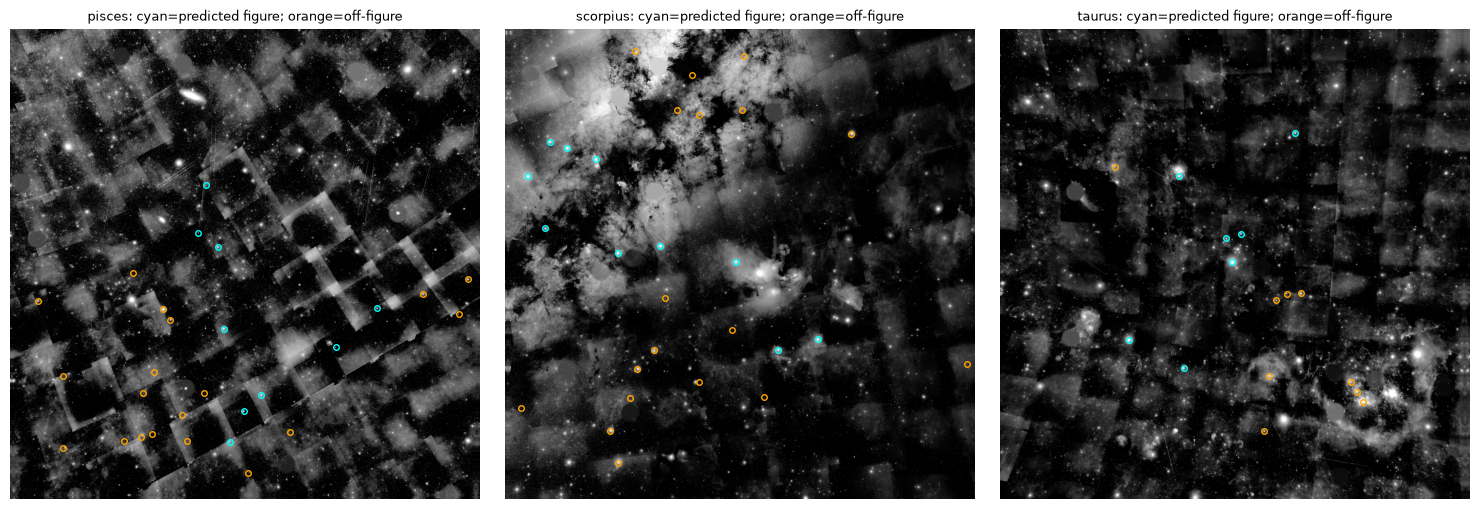

pisces figure-membership TP/FP/FN: 8 1 2
scorpius figure-membership TP/FP/FN: 10 0 0
taurus figure-membership TP/FP/FN: 6 1 0


In [5]:
for row in training_rows:
    result = cross_validation[row["Id"]]
    print("\n", row["Id"], "top geometric hypotheses:")
    for hypothesis in result["prediction"]["ranking"][:3]:
        print(hypothesis["name"], "support", hypothesis["support"],
              "median error", round(hypothesis["error"], 2),
              "evidence", round(hypothesis["score"], 2))
    errors = []
    for i, prediction in enumerate(result["prediction"]["patches"], 1):
        truth = ast.literal_eval(row[f"patch_{i:02}"])
        if truth == -1:
            if prediction != -1:
                errors.append((i, "false present"))
        elif prediction == -1:
            errors.append((i, "missed present"))
        else:
            distance = np.linalg.norm(np.array(prediction[:2])-truth[:2])
            if distance > 12:
                errors.append((i, f"localization {distance:.1f}px"))
    print("Failures:", errors)

fig, axes = plt.subplots(1, len(training_rows), figsize=(15, 5))
for ax, row in zip(np.atleast_1d(axes), training_rows):
    sky = cd.cv2.imread(str(DATA / "train" / row["Id"] / f"{row['Id']}_image.png"), 0)
    ax.imshow(sky, cmap="gray")
    for value in cross_validation[row["Id"]]["prediction"]["patches"]:
        if value != -1:
            ax.plot(value[0], value[1], "o", ms=4, mfc="none", mec="cyan" if value[2] else "orange")
    ax.set_title(row["Id"] + ": cyan=predicted figure; orange=off-figure", fontsize=9)
    ax.axis("off")
fig.tight_layout()
plt.show()

# Membership is a task requirement even though its metric role is unspecified.
for row in training_rows:
    tp = fp = fn = 0
    for i, prediction in enumerate(cross_validation[row["Id"]]["prediction"]["patches"], 1):
        truth = ast.literal_eval(row[f"patch_{i:02}"])
        actual = truth != -1 and truth[2] == 1
        guessed = prediction != -1 and prediction[2] == 1
        tp += actual and guessed
        fp += (not actual) and guessed
        fn += actual and not guessed
    print(row["Id"], "figure-membership TP/FP/FN:", tp, fp, fn)

## 6. Freeze calibration and predict competition scenes
Fit calibration to all released labeled scenes, then run the same algorithm on every sample-submission scene. Competition labels are unavailable and are never used. The sample file supplies only IDs, query counts, column order, and padding.

The exported file is a **candidate for measuring Kaggle performance**, not evidence that the 0.93–0.95 target has been reached. Generating a CSV does not submit it.

In [6]:
calibration = cd.fit_calibration(*cd.calibration_data(training_rows, training_evidence))
(OUT / "calibration.json").write_text(json.dumps(calibration, indent=2))
competition_predictions = {}
for row in sample_rows:
    evidence = cd.analyze_scene(DATA / "validation" / row["Id"], CACHE)
    sky = cd.cv2.imread(str(DATA / "validation" / row["Id"] / f"{row['Id']}_image.png"), 0)
    prediction = cd.predict_scene(evidence, calibration, patterns, sky)
    assert len(prediction["patches"]) == int(row["n_patches"])
    competition_predictions[row["Id"]] = prediction
    print(row["Id"], prediction["constellation"],
          sum(p != -1 for p in prediction["patches"]), "present /", row["n_patches"])
(OUT / "competition_diagnostics.json").write_text(json.dumps(competition_predictions, indent=2))

constellation_01 ophiuchus 18 present / 23


constellation_02 corona-australis 17 present / 24


constellation_03 camelopardalis 15 present / 31


constellation_04 canis-major 28 present / 54


constellation_05 carina 44 present / 87


...

constellation_14 lepus 17 present / 36


constellation_15 sagittarius 42 present / 69


constellation_16 canis-major 10 present / 21


constellation_17 ursa-minor 16 present / 29


563863

In [7]:
submission = cd.write_submission(DATA / "sample_submission.csv", competition_predictions,
                                 OUT / "submission_candidate.csv", patterns)
assert all(hashlib.sha256(Path(p).read_bytes()).hexdigest() == h for p, h in input_hashes.items())
print("Validated:", submission)
print("Exactly 90 columns; sample row IDs/order/counts; bounds; membership; names; -1 padding.")
print("All original Q5 PNG/CSV inputs unchanged.")
display(Markdown(f"[Download candidate CSV]({submission.as_posix()})"))

Validated: outputs/q5/submission_candidate.csv
Exactly 90 columns; sample row IDs/order/counts; bounds; membership; names; -1 padding.
All original Q5 PNG/CSV inputs unchanged.


[Download candidate CSV](outputs/q5/submission_candidate.csv)

## Sources, limits, and AI disclosure

- Q5 handout, §§4–6: task, score, schema, and data split.
- Q1–Q4 implementation: `Q1to4Solution.ipynb` (unchanged).
- Lecture 1 slides pp. 67–86 and 101–123: photometric operations and filtering.
- Lecture 2 slides pp. 106–133 and notebook: blobs, descriptors, and correlation.
- Lecture 3 notebook: transform families, least squares, RANSAC. Its teaching correspondence arrays are not used.
- OpenCV ECC and logistic evidence calibration are additional implementation choices, explicitly distinguished from the class examples.

The current official Kaggle page/scorer could not be retrieved during development. Local scores are approximate; no public or private score is fabricated. Three labeled scenes, small reference figures, saturated patches, border handling, approximate reference geometry, and competing constellations limit demonstrated generalization. The image matcher currently rejects refinements whose 81×81 neighborhood crosses a sky boundary; unseen border-centered queries are a known limitation. The coarse scale range is 0.7–1.4; local refinement accepts 0.5–2.0. Wider transformations are not guaranteed.

OpenAI Codex assisted with the implementation, experiments, evaluation, and explanations. The six earlier user prompts remain in the unchanged Q1–Q4 notebook. The subsequent available prompts are preserved below in order. No unavailable prompts or hidden model reasoning are reconstructed.

<details><summary>User request 7</summary>

Update the AGENTS.md to include the how the first 4 are solved and how to use these solution as a snippets to solve the kaggle compition

</details>

<details><summary>User request 8</summary>

Use the concepts and code discussed in the class to formulate an accurate solution to the kaggle compittion problem, the q1 to 4 are the building blocks for the compition problem, make sure to leverage those concepts to ge the accurate solution. We are aiming for well generalized model that achieves at least 93 to 95 percent on the kaggle public leaderboard and should performs equally well on private leaderboard. Discuss the solution you are thinking first before writing any code. when you do write code after late messages make sure to keep the code to the minimal and accurate.

</details>

<details><summary>User request 9</summary>

The approach sounds good, let build it in different notebook ConstellationDetection, keep the code to the minimum and accurate, and once we get the targeted result give the csv files for submission to the Kaggle

</details>

<details><summary>User request 10</summary>

Where is the csv for submission to kaggle ?

</details>